In [31]:
#写一个大循环，循环不同的分辨率
# 匹配数目与平均降水
from scipy import stats
from scipy.stats import gaussian_kde
import numpy as np
import matplotlib as mpl
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeat
import matplotlib.pyplot as plt
from cartopy.io.shapereader import Reader
import matplotlib.ticker as mticker
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from cartopy.feature import ShapelyFeature
from matplotlib.colorbar import ColorbarBase
from matplotlib.colors import BoundaryNorm
a=0.2
p = int(7 / a)
q = int(11 / a)

In [32]:
gauge_pre_grided=np.load('gauge_pre_grided.npy')
sate_pre=np.load("precip_all_hour_satellite.npy")

In [33]:
np.mean(gauge_pre_grided)

np.float64(nan)

In [34]:
np.mean(sate_pre)

np.float64(0.14930022573529828)

In [35]:
gauge_pre_grided.shape

(43848, 35, 55)

In [36]:
huatus = np.zeros((8,) + gauge_pre_grided.shape[1:])  # 前4个是地面数据，后4个是卫星数据

# RMSE/Bias 仍旧屏蔽双零降水，KGE 使用原始序列
sate_rmse = np.array(sate_pre, copy=True)
gauge_rmse = np.array(gauge_pre_grided, copy=True)
mask_no_precip = (gauge_rmse < 0.1) & (sate_rmse < 0.1)
sate_rmse[mask_no_precip] = np.nan
gauge_rmse[mask_no_precip] = np.nan
pre_minus = sate_rmse - gauge_rmse


# 定义每年的小时数（已知两个闰年）
hours_per_year = [8784, 8760, 8760, 8760, 8784]

# 预计算各季节起始索引（基于每年1月1日0时为起点）
season_slices = [
    # 春季：3-5月（按闰年计算，实际使用时根据年份索引选择）
    {"start": 31*24 + 28*24, "end": 31*24 + 28*24 + 92*24},  # 3/1 0:00 ~ 5/31 23:00
    
    # 夏季：6-8月
    {"start": 31*24 + 28*24 + 92*24, "end": 31*24 + 28*24 + 92*24 + 92*24},
    
    # 秋季：9-11月
    {"start": 31*24 + 28*24 + 184*24, "end": 31*24 + 28*24 + 184*24 + 91*24},
    
    # 冬季：当年12月 + 次年1-2月（修正为仅当前年）
    {"start": 334*24, "end": 365*24},  # 12/1 0:00 ~ 12/31 23:00
    {"pre_start": 0, "pre_end": 59*24}  # 1/1 0:00 ~ 2/28 23:00
]

# 动态生成各年实际索引（考虑闰年）
def get_season_indices(year_idx, is_leap):
    base = sum(hours_per_year[:year_idx])
    leap_offset = 24 if is_leap else 0
    
    return {
        "spring": (
            base + (31*24 + 28*24 + leap_offset),  # 3/1 0:00
            base + (31*24 + 28*24 + 92*24 + leap_offset)
        ),
        "summer": (
            base + (31*24 + 28*24 + 92*24 + leap_offset),
            base + (31*24 + 28*24 + 184*24 + leap_offset)
        ),
        "autumn": (
            base + (31*24 + 28*24 + 184*24 + leap_offset),
            base + (31*24 + 28*24 + 275*24 + leap_offset)
        ),
        "winter": [
            (base + 334*24, base + (366 if is_leap else 365)*24),  # 12/1 ~ 年底
            (base, base + 59*24 + (24 if is_leap else 0))          # 1/1 ~ 2/29/28
        ]
    }


# 初始化季节数据容器
minus_seasons = [[] for _ in range(4)]
sate_seasons = [[] for _ in range(4)]
gauge_seasons = [[] for _ in range(4)]

# 处理每个年份的数据
cursor = 0
for year in range(5):
    is_leap = (hours_per_year[year] == 8784)
    indices = get_season_indices(year, is_leap)
    
    # 切割四季数据
    for i, season in enumerate(["spring", "summer", "autumn"]):
        start, end = indices[season]
        minus_seasons[i].append(pre_minus[start:end])
        sate_seasons[i].append(sate_pre[start:end])
        gauge_seasons[i].append(gauge_pre_grided[start:end])
    
    # 冬季特殊处理：12月 + 1-2月（同一年内）
    winter12 = pre_minus[indices["winter"][0][0]:indices["winter"][0][1]]
    winter1_2 = pre_minus[indices["winter"][1][0]:indices["winter"][1][1]]
    minus_seasons[3].append(np.concatenate([winter1_2, winter12]))
    
    sate_winter12 = sate_pre[indices["winter"][0][0]:indices["winter"][0][1]]
    sate_winter1_2 = sate_pre[indices["winter"][1][0]:indices["winter"][1][1]]
    sate_seasons[3].append(np.concatenate([sate_winter1_2, sate_winter12]))

    gauge_winter12 = gauge_pre_grided[indices["winter"][0][0]:indices["winter"][0][1]]
    gauge_winter1_2 = gauge_pre_grided[indices["winter"][1][0]:indices["winter"][1][1]]
    gauge_seasons[3].append(np.concatenate([gauge_winter1_2, gauge_winter12]))

# 计算平均值
for i in range(4):
    concatenated_minus = np.concatenate(minus_seasons[i], axis=0)
    huatus[i] = np.sqrt(np.nanmean(concatenated_minus**2, axis=0))
    huatus[i+4] = np.nanmean(concatenated_minus, axis=0)



C:\Users\Administrator\AppData\Local\Temp\ipykernel_8020\1973806901.py:90: RuntimeWarning: Mean of empty slice
  huatus[i] = np.sqrt(np.nanmean(concatenated_minus**2, axis=0))
C:\Users\Administrator\AppData\Local\Temp\ipykernel_8020\1973806901.py:91: RuntimeWarning: Mean of empty slice
  huatus[i+4] = np.nanmean(concatenated_minus, axis=0)


In [55]:

MIN_PRECIP_FRACTION = 0.0#3 #至少1%的非零降水样本


def compute_kge_parts(sim_list, obs_list, min_precip_fraction=MIN_PRECIP_FRACTION):
    sim = np.concatenate(sim_list, axis=0)#五年合并
    obs = np.concatenate(obs_list, axis=0)#五年合并
    common_mask = (~np.isnan(sim)) & (~np.isnan(obs))#筛除地基站的nan值
    sim_valid = np.where(common_mask, sim, np.nan)
    obs_valid = np.where(common_mask, obs, np.nan)

    valid_counts = np.sum(~np.isnan(sim_valid) & ~np.isnan(obs_valid), axis=0)


    mean_sim = np.nanmean(sim_valid, axis=0)

    mean_obs = np.nanmean(obs_valid, axis=0)

    std_sim = np.nanstd(sim_valid, axis=0)

    std_obs = np.nanstd(obs_valid, axis=0)


    with np.errstate(divide='ignore', invalid='ignore'):
        beta = mean_sim / mean_obs
        alpha = std_sim / std_obs
        covariance = np.nanmean((sim_valid - mean_sim) * (obs_valid - mean_obs), axis=0)
        r = covariance / (std_sim * std_obs)

        kge = 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)


    precip_counts = np.sum(obs_valid >= 0.1, axis=0)
    with np.errstate(divide='ignore', invalid='ignore'):
        precip_fraction = np.where(valid_counts > 0, precip_counts / valid_counts, 0)
        print(precip_fraction)
    insufficient = (
        (valid_counts < 2)
        | np.isnan(mean_sim)
        | np.isnan(mean_obs)
        | (precip_fraction < min_precip_fraction)
    )
    print(insufficient)
    for arr in (beta, alpha, r, kge):
        arr[insufficient] = np.nan

    return kge, r, alpha, beta



kge, r_comp, alpha_comp, beta_comp = compute_kge_parts(sate_seasons[0], gauge_seasons[0])

C:\Users\Administrator\AppData\Local\Temp\ipykernel_8020\4080689256.py:14: RuntimeWarning: Mean of empty slice
  mean_sim = np.nanmean(sim_valid, axis=0)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_8020\4080689256.py:16: RuntimeWarning: Mean of empty slice
  mean_obs = np.nanmean(obs_valid, axis=0)
c:\ProgramData\miniconda3\envs\pystudy\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


[[0.15942029 0.14015615 0.11868092 ... 0.13108071 0.13431981 0.12621183]
 [0.15815217 0.13244286 0.11413043 ... 0.13057173 0.         0.11216574]
 [0.12418478 0.12663043 0.1013587  ... 0.         0.         0.        ]
 ...
 [0.03082061 0.03205621 0.04646739 ... 0.         0.         0.        ]
 [0.04121906 0.04807139 0.04012681 ... 0.         0.         0.        ]
 [0.03514493 0.03097826 0.03405797 ... 0.         0.         0.        ]]
[[False False False ... False False False]
 [False False False ... False  True False]
 [False False False ...  True  True  True]
 ...
 [False False False ...  True  True  True]
 [False False False ...  True  True  True]
 [False False False ...  True  True  True]]


C:\Users\Administrator\AppData\Local\Temp\ipykernel_8020\4080689256.py:26: RuntimeWarning: Mean of empty slice
  covariance = np.nanmean((sim_valid - mean_sim) * (obs_valid - mean_obs), axis=0)


In [56]:
kge_maps = np.full((4,) + gauge_pre_grided.shape[1:], np.nan)
r_maps = np.full_like(kge_maps, np.nan)
alpha_maps = np.full_like(kge_maps, np.nan)
beta_maps = np.full_like(kge_maps, np.nan)
seasonal_kge_mean = np.full(4, np.nan)

for idx in range(4):
    kge, r_comp, alpha_comp, beta_comp = compute_kge_parts(sate_seasons[idx], gauge_seasons[idx])
    kge_maps[idx] = kge
    r_maps[idx] = r_comp
    alpha_maps[idx] = alpha_comp
    beta_maps[idx] = beta_comp
    seasonal_kge_mean[idx] = np.nanmean(kge)

season_names = ["Spring", "Summer", "Fall", "Winter"]
for idx, name in enumerate(season_names):
    mean_val = seasonal_kge_mean[idx]
    if np.isnan(mean_val):
        print(f"{name} mean KGE: NaN")
    else:
        print(f"{name} mean KGE: {mean_val:.3f}")

C:\Users\Administrator\AppData\Local\Temp\ipykernel_8020\4080689256.py:14: RuntimeWarning: Mean of empty slice
  mean_sim = np.nanmean(sim_valid, axis=0)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_8020\4080689256.py:16: RuntimeWarning: Mean of empty slice
  mean_obs = np.nanmean(obs_valid, axis=0)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_8020\4080689256.py:26: RuntimeWarning: Mean of empty slice
  covariance = np.nanmean((sim_valid - mean_sim) * (obs_valid - mean_obs), axis=0)


[[0.15942029 0.14015615 0.11868092 ... 0.13108071 0.13431981 0.12621183]
 [0.15815217 0.13244286 0.11413043 ... 0.13057173 0.         0.11216574]
 [0.12418478 0.12663043 0.1013587  ... 0.         0.         0.        ]
 ...
 [0.03082061 0.03205621 0.04646739 ... 0.         0.         0.        ]
 [0.04121906 0.04807139 0.04012681 ... 0.         0.         0.        ]
 [0.03514493 0.03097826 0.03405797 ... 0.         0.         0.        ]]
[[False False False ... False False False]
 [False False False ... False  True False]
 [False False False ...  True  True  True]
 ...
 [False False False ...  True  True  True]
 [False False False ...  True  True  True]
 [False False False ...  True  True  True]]
[[0.17291667 0.13759058 0.1053442  ... 0.13687834 0.13361718 0.1245471 ]
 [0.16322464 0.1307971  0.11141304 ... 0.11895271 0.         0.1103618 ]
 [0.15208333 0.14012681 0.10172101 ... 0.         0.         0.        ]
 ...
 [0.07563406 0.09214955 0.08650362 ... 0.         0.         0.     

In [57]:
gauge_seasons[3][4].mean()

np.float64(nan)

In [58]:
print(np.nanmean(huatus[0]),np.nanmean(huatus[1]),np.nanmean(huatus[2]),np.nanmean(huatus[3]))
print(np.nanmean(huatus[4]),np.nanmean(huatus[5]),np.nanmean(huatus[6]),np.nanmean(huatus[7]))
print(np.array([np.nanmean(huatus[4]),np.nanmean(huatus[5]),np.nanmean(huatus[6]),np.nanmean(huatus[7])]).mean())


1.6452600361228382 3.3472762511551832 1.8419051347087285 1.2573544759141313
0.24735438401197413 0.35331888197030387 0.19784146715215448 0.3839116971098386
0.29560660756106777


In [59]:
plt.rcParams["font.sans-serif"] = ["Arial"]  # 用于显示中文,Arial
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["axes.unicode_minus"] = False  # 用于显示中文


# --设置shp路径，数据集已公开
shp_path = r"E:\0000000000\map_data\bou2_4p.dbf"
# --设置tif路径，数据集已公开
tif_path = r"E:\0000000000\map_data\地形数据\NE1_50M_SR_W.tif"

bins = np.arange(0,5.52,0.02)#,np.arange(2,2.5,0.01))
#bins = np.arange(0,0.2,0.01)
nbin = len(bins) + 1
cmap1 =plt.get_cmap("Spectral_r", nbin)
norm1 = mpl.colors.BoundaryNorm(bins, nbin,extend='both')

bins = np.arange(-1.,1.01,0.01)
#bins = np.arange(0,0.2,0.01)
nbin = len(bins) + 1
cmap2 = plt.get_cmap("coolwarm", nbin)
norm2 = mpl.colors.BoundaryNorm(bins, nbin,extend='both')

bins = np.arange(-1., 1.05, 0.05)
nbin = len(bins) + 1
cmap3 = plt.get_cmap("RdBu_r", nbin)
norm3 = mpl.colors.BoundaryNorm(bins, nbin, extend='both')


# import matplotlib as mpl
# import matplotlib.colors as colors
# colorslist = ['white','skyblue','Cyan','red']
# # colorslist = ['white','green','blue','red']
# #将四种色插值为具有300个渐变色的色板
# bins =  np.arange(0,2.52,0.02)
# nbin = len(bins) + 2
# cmap1 = colors.LinearSegmentedColormap.from_list('123',colorslist,nbin)
# norm1 = mpl.colors.BoundaryNorm(bins, nbin, extend='both')

In [60]:
print(np.nanstd(huatus[0])/np.nanmean(huatus[0]),np.nanstd(huatus[1])/np.nanmean(huatus[1]),np.nanstd(huatus[2])/np.nanmean(huatus[2]),np.nanstd(huatus[3])/np.nanmean(huatus[3]))
print(np.nanstd(huatus[4])/np.nanmean(huatus[4]),np.nanstd(huatus[5])/np.nanmean(huatus[5]),np.nanstd(huatus[6])/np.nanmean(huatus[6]),np.nanstd(huatus[7])/np.nanmean(huatus[7]))

0.21494805007431042 0.17307558188219066 0.2855632074377529 0.6635839365592164
0.4325317402533991 0.5054652970717959 0.735776355284936 0.9339930089949692


In [61]:
num=np.load("num_station_gauge.npy")
huatus[1]
num_flat = num.flatten()
huatus_1_flat = huatus[1].flatten()
valid_mask = ~np.isnan(num_flat) & ~np.isnan(huatus_1_flat)
num_valid = num_flat[valid_mask]
huatus_1_valid = huatus_1_flat[valid_mask]

# 使用scipy.stats.pearsonr计算相关系数和p值
correlation_coef, p_value = stats.pearsonr(num_valid, huatus_1_valid)
sample_size = len(num_valid)  # 样本数

# 输出结果
print(f"相关系数 (r): {correlation_coef:.4f}")
print(f"p值: {p_value:.4e}")
print(f"样本数 (n): {sample_size}")

# 如果需要，也可以保留原来的相关系数矩阵形式
correlation_matrix = np.corrcoef(num_valid, huatus_1_valid)
print(f"\n相关系数矩阵:\n{correlation_matrix}")

相关系数 (r): -0.3305
p值: 3.8768e-44
样本数 (n): 1681

相关系数矩阵:
[[ 1.         -0.33052843]
 [-0.33052843  1.        ]]


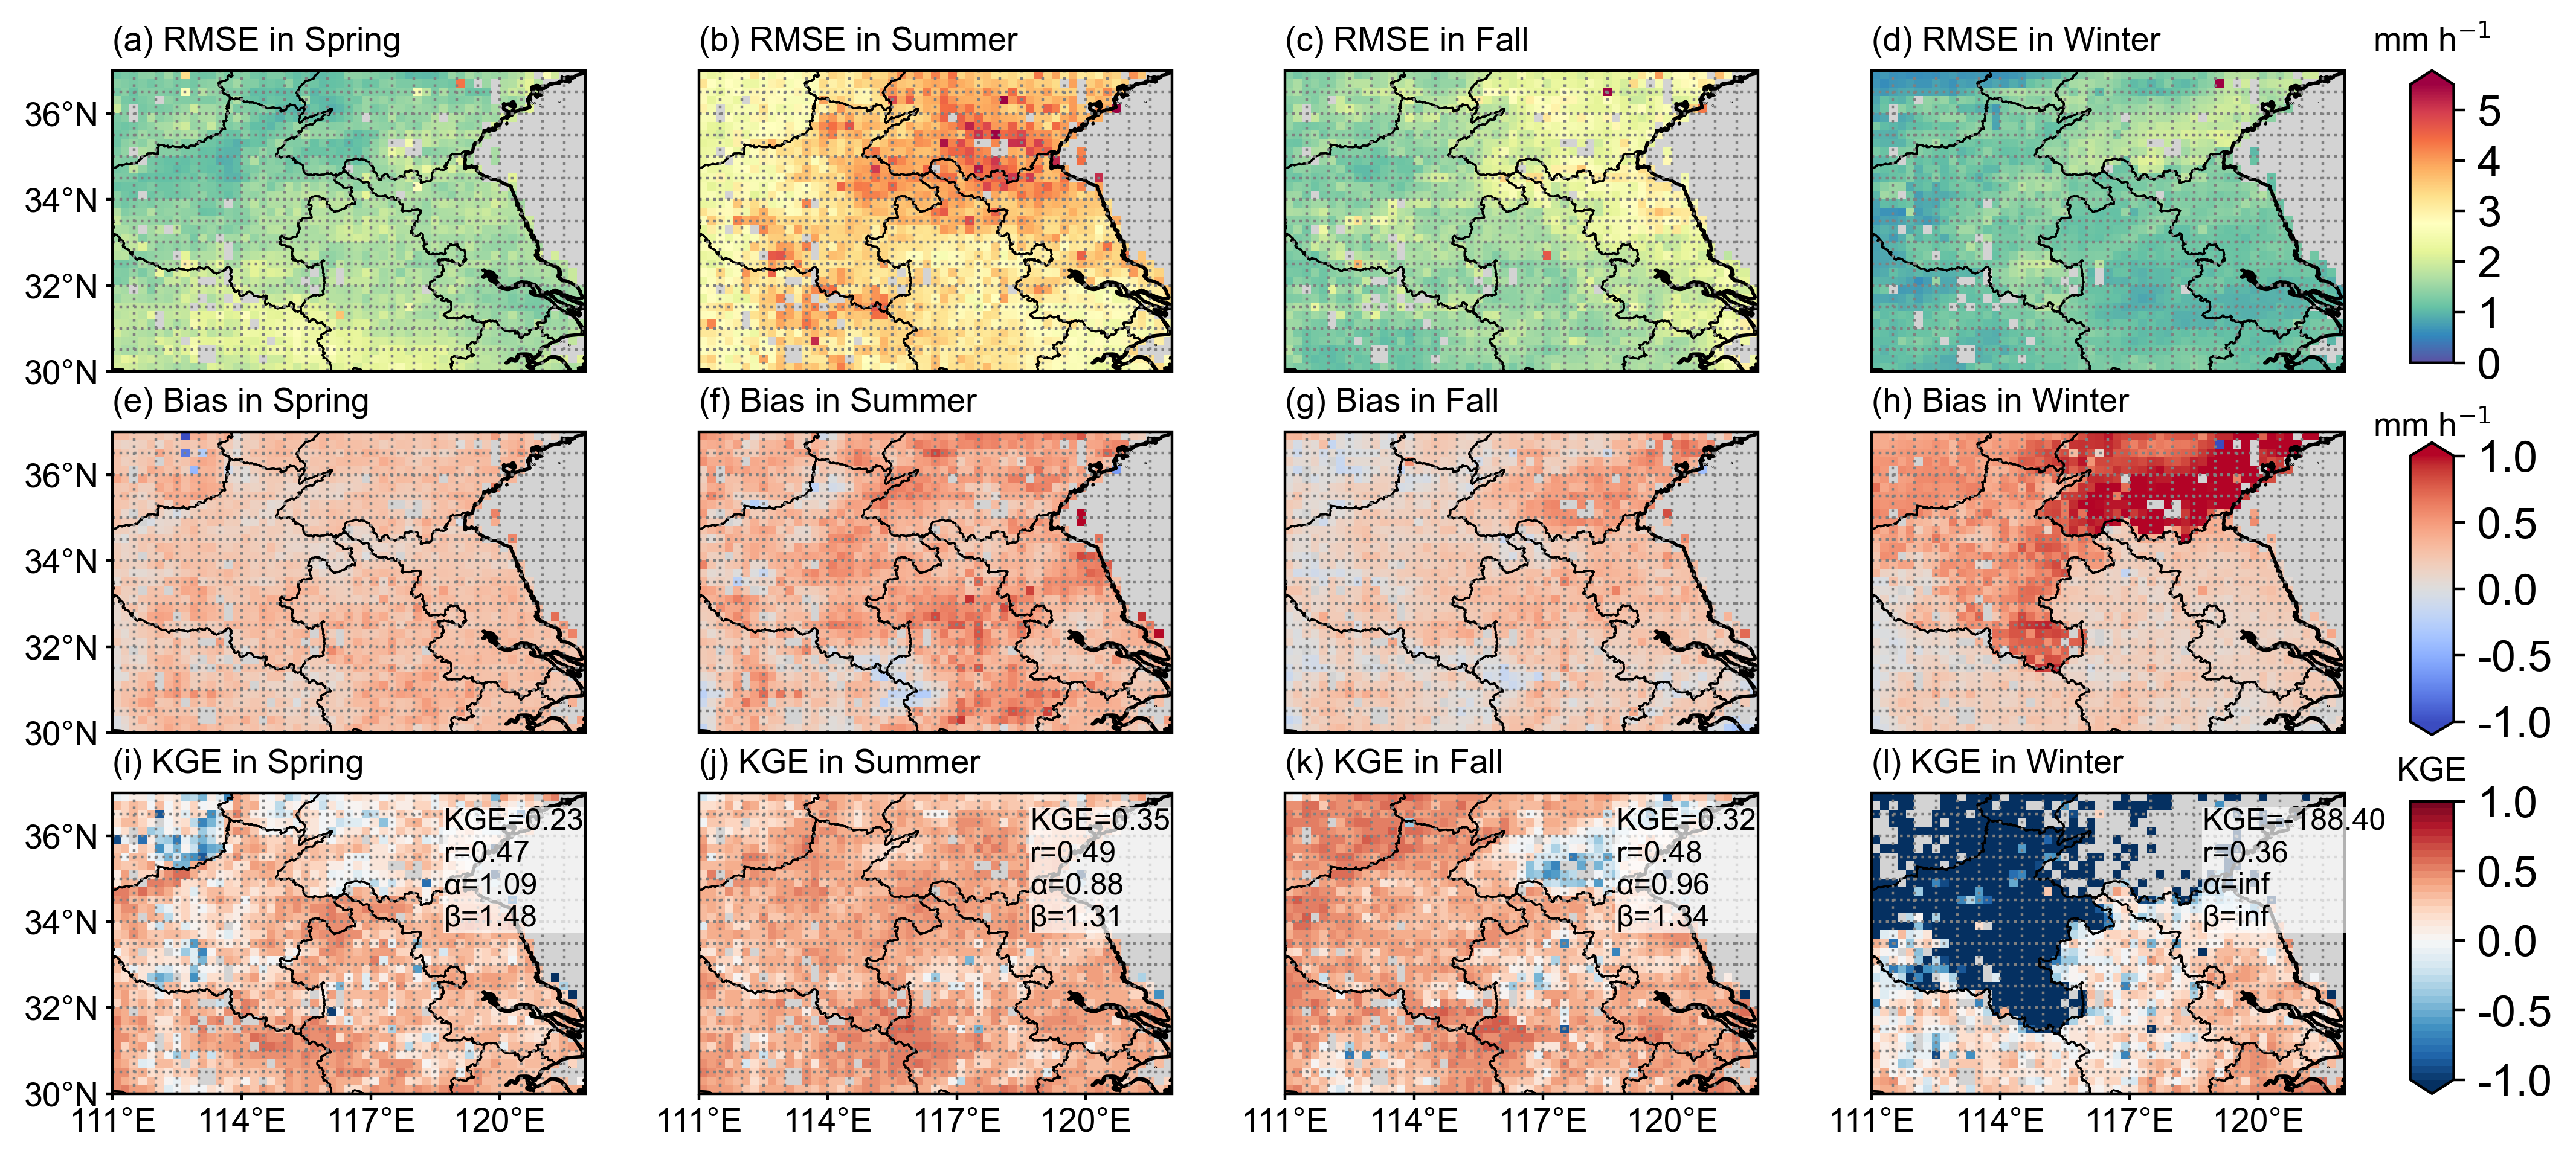

In [62]:

fig, axs = plt.subplots(3, 4, figsize=(12, 5.5), dpi=400, subplot_kw={'projection': ccrs.PlateCarree()})
axs = axs.ravel()

def format_component(value):
    return "NaN" if np.isnan(value) else f"{value:.2f}"

for i in range(12):
    ax = axs[i]
    ax.coastlines()
    ax.patch.set_facecolor("lightgray")
    provinces = ShapelyFeature(Reader(shp_path).geometries(), ccrs.PlateCarree(), edgecolor="k", facecolor="none")
    ax.add_feature(provinces, lw=0.6, zorder=2)

    ax.set_extent([111, 122, 30, 37], crs=ccrs.PlateCarree())

    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.8, color="gray", linestyle=":")
    gl.top_labels = False
    gl.bottom_labels = False
    gl.right_labels = False
    gl.left_labels = False
    gl.xlocator = mticker.FixedLocator(np.arange(111, 122, 0.5))
    gl.ylocator = mticker.FixedLocator(np.arange(30, 37, 0.5))

    if i % 4 == 0:
        ax.set_yticks(np.arange(30, 38, 2), crs=ccrs.PlateCarree())
        ax.yaxis.set_major_formatter(LatitudeFormatter())
        ax.tick_params(labelcolor="k", length=2, labelsize=10, rotation=0, pad=2)

    if i >= 8:
        ax.set_xticks(np.arange(111, 123, 3), crs=ccrs.PlateCarree())
        ax.xaxis.set_major_formatter(LongitudeFormatter())
        ax.tick_params(labelcolor="k", length=2, labelsize=10, rotation=0, pad=2)

    row_idx = i // 4
    if row_idx == 0:
        data = huatus[i]
        cmap, norm = cmap1, norm1
    elif row_idx == 1:
        data = huatus[i]
        cmap, norm = cmap2, norm2
    else:
        data = kge_maps[i - 8]
        cmap, norm = cmap3, norm3

    im = ax.imshow(
        data,
        cmap=cmap,
        norm=norm,
        origin="lower",
        extent=(111, 122, 30, 37),
    )

    if row_idx == 2:
        season_idx = i - 8
        mean_kge = seasonal_kge_mean[season_idx]
        mean_r = np.nanmean(r_maps[season_idx])
        mean_alpha = np.nanmean(alpha_maps[season_idx])
        mean_beta = np.nanmean(beta_maps[season_idx])
        annotation = (
            f"KGE={format_component(mean_kge)}\n"
            f"r={format_component(mean_r)}\n"
            f"α={format_component(mean_alpha)}\n"
            f"β={format_component(mean_beta)}"
        )
        ax.text(
            0.7,
            0.95,
            annotation,
            transform=ax.transAxes,
            fontsize=9,
            va='top',
            ha='left',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=0.2)
        )

    if i == 3:
        rmse_im = im
    if i == 7:
        bias_im = im
    if i == 11:
        kge_im = im

font = {'size': 10}

cbar_ax = fig.add_axes([0.92, 0.66, 0.015, 0.22])
cbar = plt.colorbar(rmse_im, cax=cbar_ax, extend='max', orientation='vertical', ticks=np.arange(0, 5.5, 1))
cbar.ax.set_title('mm h$^{-1}$', fontdict=font)
cbar.ax.tick_params(labelsize=13)
cbar.minorticks_off()

cbar_ax = fig.add_axes([0.92, 0.38, 0.015, 0.22])
cbar = plt.colorbar(bias_im, cax=cbar_ax, extend='both', orientation='vertical', ticks=np.arange(-2, 2.5, 0.5))
cbar.ax.set_title('mm h$^{-1}$', fontdict=font)
cbar.ax.tick_params(labelsize=13)
cbar.minorticks_off()

cbar_ax = fig.add_axes([0.92, 0.11, 0.015, 0.22])
cbar = plt.colorbar(kge_im, cax=cbar_ax, extend='min', orientation='vertical', ticks=np.arange(-1, 1.25, 0.5))
cbar.ax.set_title('KGE', fontdict=font)
cbar.ax.tick_params(labelsize=13)
cbar.minorticks_off()

axs[0].set_title('(a) RMSE in Spring', fontsize=10, loc='left')
axs[1].set_title('(b) RMSE in Summer', fontsize=10, loc='left')
axs[2].set_title('(c) RMSE in Fall', fontsize=10, loc='left')
axs[3].set_title('(d) RMSE in Winter', fontsize=10, loc='left')
axs[4].set_title('(e) Bias in Spring', fontsize=10, loc='left')
axs[5].set_title('(f) Bias in Summer', fontsize=10, loc='left')
axs[6].set_title('(g) Bias in Fall', fontsize=10, loc='left')
axs[7].set_title('(h) Bias in Winter', fontsize=10, loc='left')
axs[8].set_title('(i) KGE in Spring', fontsize=10, loc='left')
axs[9].set_title('(j) KGE in Summer', fontsize=10, loc='left')
axs[10].set_title('(k) KGE in Fall', fontsize=10, loc='left')
axs[11].set_title('(l) KGE in Winter', fontsize=10, loc='left')

plt.show()